# 🇰🇷 한국어 글쓰기 스타일 변환
## 응용정보공학전공 2024106111 민지은
### Scenario 18 — 예시 문장을 보고 해당 문체로 새로운 내용을 생성하는 정책을 SFT로 주입한 파인튜닝 프로젝트


예시 문장과 작성할 내용을 함께 입력하면, 예시 문장의 말투·어휘·문장 구조를 유지하면서 새로운 글을 생성하는 모델입니다. 기존 모델은 예시 문장의 말투를 무시하고 마크다운·정형화된 형식을 따랐습니다. 이는 스타일 지식이 없는 게 아니라 정책 결함 문제로, SFT를 통해 교정했습니다.

## 설치 & GPU


In [ ]:
!nvidia-smi


Sat Jun 20 07:45:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P0             29W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%%capture
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps trl peft accelerate bitsandbytes
!pip install -q datasets


In [ ]:
import warnings
warnings.filterwarnings("ignore")

## 1 — 모델 및 토크나이저 로딩

> **모델 = Gemma 4 (E2B)**
>
> - **결정**: `unsloth/gemma-4-E2B-it` (instruct).
> - **왜**: E2B는 초경량(effective 2B)이라 무료 T4에서 학습 가능. instruct라 대화/지시는 알지만 *스타일 전환 정책*은 미학습 → 결함 재현에 적합.

In [ ]:
from unsloth import FastModel
import torch

base_model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-4-E2B-it",
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.8: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

## 1. 결함 재현 (Before) — 무엇을 보는가

같은 시스템 지시("예시 문체에 맞춰 작성하라")를 줘도, 소형 instruct 모델은 예시 문장을 무시하고 일반적인 텍스트 생성 패턴을 따른다. 이는 정렬(helpfulness) 편향의 결과로, 소형 모델은 프롬프트만으로 예시 기반 스타일 전환 정책을 안정적으로 수행하지 못한다. → 노트북 2장에서 2개 사례(할머니 말투, 인터넷 슬랭)로 스타일 미반영 출력을 눈으로 확인한다.

## 2. Before — 기존 모델 출력 확인
파인튜닝 전, 같은 시스템 지시를 줘도 **정답을 바로 주는지** 본다.


In [ ]:
SYSTEM = "시나리오[18]: 요청한 문체/형식/목적에 맞춰 글을 작성하거나 다듬어 주세요."

PROMPTS = {
    "사례1_할머니말투": (
        '예시 문장: "아이고, 우리 강아지 똥강아지 귀여워라."\n'
        '작성할 내용: 할머니가 손자에게 옛날 이야기를 들려주는 상황'
    ),
    "사례2_인터넷슬랭": (
        '예시 문장: "갑자기 TMI인데 어제 꿀잼 드라마 정주행했음ㅋㅋ"\n'
        '작성할 내용: 새로 나온 드라마에 대해 온라인 커뮤니티에서 의견을 나누는 글'
    )
}

def ask(model, tokenizer, question, max_new_tokens=200):
    msgs = [{"role": "user", "content": [{"type": "text", "text": SYSTEM + "\n\n" + question}]}]
    inputs = tokenizer.apply_chat_template(
        msgs, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt"
    ).to("cuda")
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.95,
        top_k=64,
    )
    return tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

print("=" * 60)
print("Before (베이스 모델)")
print("=" * 60)
for name, prompt in PROMPTS.items():
    print(f"\n[{name}]\n입력: {prompt[:50]}...")
    print(f"출력: {ask(base_model, tokenizer, prompt)}")
    print("-" * 60)

Before (베이스 모델)

[사례1_할머니말투]
입력: 예시 문장: "아이고, 우리 강아지 똥강아지 귀여워라."
작성할 내용: 할머니가 손자에게 ...
출력: ## 시나리오 [18]

**장면:** 햇살이 잘 드는 거실, 할머니와 손자가 편안하게 앉아 있다. 할머니는 낡은 앨범을 들고 있고, 손자는 호기심 가득한 눈으로 할머니를 바라보고 있다.

**등장인물:**

* **할머니 (70대 후반):** 따뜻하고 정겨운 인상. 목소리에는 세월의 깊이가 묻어난다.
* **손자 (10세):** 밝고 순수한 호기심이 넘친다.

**(장면 시작)**

**할머니:** (앨범을 조심스럽게 넘기며, 나지막하고 다정한 목소리로) 아이고, 우리 강아지 똥강아지, 이리 와서 할미 옆에 앉아 보렴.

**(손자가 할머니 옆에 바싹 다
------------------------------------------------------------

[사례2_인터넷슬랭]
입력: 예시 문장: "갑자기 TMI인데 어제 꿀잼 드라마 정주행했음ㅋㅋ"
작성할 내용: 새로 나온...
출력: ## 🎬 [드라마 제목] 정주행 후기! 여러분은 어떻게 보셨나요? 🤔

**제목:** [드라마 제목] 드디어 정주행 완료! 🤯 솔직 후기 & 여러분의 생각은?

**본문:**

안녕하세요! 👋 다들 [드라마 제목] 보셨나요? 저 드디어 주말 내내 정주행 끝냈습니다! 😭✨

솔직히 시작할 때부터 '이거 재밌겠다' 싶었는데, 막상 보니까 몰입감이 장난 아니더라고요. 특히 [가장 인상 깊었던 장면/캐릭터 언급] 부분은 진짜 심장 쫄깃해서 몇 번이나 돌려봤는지 몰라요 ㅋㅋㅋ 😵‍💫

**👍 좋았던 점:**

1. **스토리 전개:** 예측 불가능한 전개가 계속해서 다음 화를 보게 만드는 묘미가 있었어요. 스포일러 방지
------------------------------------------------------------


## Before 실험: 기존 모델 출력 확인 정리

파인튜닝 전, 동일한 시스템 지시를 주었을 때 모델이 기대한 스타일 전환을 수행하는지 확인한다.

### 실험 결과 요약

| | 입력 예시 문장 | 기대 출력 | 실제 출력 | 결과 |
|---|---|---|---|---|
| **사례 1** | `"아이고, 우리 강아지 똥강아지 귀여워라."` (할머니 말투) | 동일 말투로 옛날이야기 생성 | 마크다운 시나리오 형식 문서, 구어체 미반영 | ❌ |
| **사례 2** | `"갑자기 TMI인데 어제 꿀잼 드라마 정주행했음ㅋㅋ"` (인터넷 슬랭) | 커뮤니티 구어체·밈 표현 포함 글 | 정형화된 후기 게시글 형식, 슬랭 미반영 | ❌ |

### 관찰
- 두 사례 모두 모델이 예시 문체를 **참고하지 않고** 일반적인 텍스트 생성 패턴을 따랐다.
- 스타일 지식 자체가 없는 것이 아니라, **예시 문장을 보고 해당 스타일로 전환하는 정책**이 없는 상태.

→ 이는 지식 부재가 아닌 **정책 결함** 문제로 판단 → SFT로 교정 가능하다는 가설 수립.

## 3. LoRA Adapter 설정

- **학습 범위 = LoRA Adapter only**
- Base model의 원본 가중치는 고정하고, LoRA가 적용된 일부 레이어의 파라미터만 업데이트하였다.
- `finetune_language_layers=True`를 사용하여 언어 모델 레이어만 학습하였다.
- `finetune_vision_layers=False`로 vision layer는 학습에서 제외하였다.

| 변수 | 사용값 |
|---|---|
| learning rate | 2e-4 |
| epochs | 3 |
| LoRA r | 16 |
| LoRA alpha | 32 |
| target modules | q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj |
| effective batch (batch × accum) | 16 × 2 = 32 |




In [ ]:
ft_model = FastModel.get_peft_model(
    base_model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=32,  # 2×r, 경험칙 표준값
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    finetune_language_layers=True,
    finetune_vision_layers=False,
    random_state=42,
)

Unsloth: Explicit target_modules are constrained by the finetune_(vision|language|attention|mlp) filters; adapters attach only where both select.


# 4. 데이터 임포트 + Data Recipes

In [ ]:
from unsloth.chat_templates import get_chat_template
from datasets import load_dataset

dataset = load_dataset("coastral/korean-writing-style-instruct", split="train")

# 컬럼명 확인
print(dataset.column_names)
print(dataset[0])

['conversations']
{'conversations': [{'from': 'human', 'value': '예시 문장: "이 책은 조선 시대의 역사와 문화를 담고 있노라."\n작성할 내용: 연려실기술의 저자와 그 책의 중요성에 대해 설명하시오.'}, {'from': 'gpt', 'value': '연려실기술은 곧 이긍익이 저술한 것이니라. 이 책은 실로 조선 시대의 귀중한 사료로서, 그 가치를 헤아리기 어려울 정도로다. 이긍익은 당대의 명망 있는 학자로, 그의 해박한 지식과 예리한 통찰력으로 우리 역사의 숨은 면모를 밝혀내었느니라. 연려실기술은 조선 건국부터 숙종 대까지의 사실을 망라하여, 정치, 경제, 사회, 문화 등 다방면의 내용을 담고 있으매, 후세 역사가들에게 귀중한 자료가 되었도다. 이 책의 중요성은 단순히 사실의 나열에 그치지 않고, 당시의 시대상을 생생히 전하는 데 있나니, 이는 우리 선조들의 삶과 사상을 이해하는 데 큰 도움이 되느니라.'}]}


In [ ]:
# 중복 제거
texts = [ex["conversations"][0]["value"] for ex in dataset]
seen = set()
clean_indices = []
for i, t in enumerate(texts):
    if t not in seen:
        seen.add(t)
        clean_indices.append(i)
dataset = dataset.select(clean_indices)
print(f"중복 제거 후: {len(dataset)}")

중복 제거 후: 28866


In [ ]:
def is_quality(example):
    convo = example["conversations"]
    user_text = convo[0]["value"]
    assistant_text = convo[1]["value"]

    # 기준 1: 응답 150자 이상
    if len(assistant_text) < 150:
        return False
    # 기준 2: 응답 1000자 이하 (max_seq_length 초과 방지)
    if len(assistant_text) > 1000:
        return False
    # 기준 3: user 입력 20자 이상
    if len(user_text) < 20:
        return False
    # 기준 4: 스타일 지시가 있는 샘플
    if "예시" not in user_text and "말투" not in user_text and "스타일" not in user_text and "처럼" not in user_text:
        return False
    # 기준 5: 깨진 인코딩 없음
    if "\ufffd" in assistant_text:
        return False
    # 기준 6: 두 턴 구조 확인
    if len(convo) != 2:
        return False

    return True

dataset_filtered = dataset.filter(is_quality)
print(f"필터링 후: {len(dataset_filtered)}")

필터링 후: 23709


In [ ]:
# 샘플링
dataset = dataset_filtered.shuffle(seed=42).select(range(1000))
print(f"샘플링 후: {len(dataset)}")

샘플링 후: 1000


In [ ]:
# Train / Test 분리

dataset_split = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = dataset_split["train"]
eval_dataset = dataset_split["test"]
print(f"학습: {len(train_dataset)}개, 검증: {len(eval_dataset)}개")

학습: 900개, 검증: 100개


In [ ]:
# chat template 적용 (변환 + 포맷 한 번에)
tokenizer = get_chat_template(tokenizer, chat_template="gemma-4")

def apply_template(examples):
    texts = []
    for convo in examples["conversations"]:
        messages = [
            {"role": "user" if turn["from"] == "human" else "assistant",
             "content": turn["value"]}
            for turn in convo
        ]
        text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        texts.append(text)
    return {"text": texts}

train_dataset = train_dataset.map(apply_template, batched=True)
eval_dataset  = eval_dataset.map(apply_template, batched=True)

In [ ]:
print(f"\n샘플 확인:")
print("user:", train_dataset[0]["conversations"][0]["value"][:100])
print(f"assistant 길이: {len(train_dataset[0]['conversations'][1]['value'])}자")
print("\nchat template 적용 결과:")
print(train_dataset[0]["text"][:300])


샘플 확인:
user: 옛날 할아버지가 된 듯한 말투로, 장승에 대해 설명해주시오. 특히 장승의 역할과 모양, 그리고 한국의 문화유산으로서의 의미를 강조해주세요.
assistant 길이: 763자

chat template 적용 결과:
<bos><|turn>user
옛날 할아버지가 된 듯한 말투로, 장승에 대해 설명해주시오. 특히 장승의 역할과 모양, 그리고 한국의 문화유산으로서의 의미를 강조해주세요.<turn|>
<|turn>model
허허, 그래. 이 늙은이가 장승에 대해 한 수 가르쳐주겠네.

옛날옛적, 우리 마을 어귀엔 늘 한 쌍의 장승이 서 있었다네. 천하대장군과 지하여장군, 이 둘이 마을을 지키는 파수꾼 역할을 했지. 

자네, 장승이 뭔지 아는가? 그건 말이야, 나무나 돌로 만든 기둥인데, 꼭대기엔 사람 얼굴을 새겨 넣었어. 우리 조상들의 지혜가 담긴


## 5. SFTTrainer 학습

> **학습 방법 = SFT + `train_on_responses_only`**
>
> - **결정**: SFT (지도 미세조정), 응답 토큰에만 loss.
> - **왜**: 결함이 정책(행동) 문제이므로 `(입력 → 모범 스타일 출력)` 모방이 정확한 학습 신호. `train_on_responses_only`로 user 턴을 마스킹해 모델이 질문을 외우지 않고 **스타일 생성 정책**만 학습하게 함.
> - **대안**: CPT(지식 부재일 때) / DPO(우열 쌍이 있을 때) / 전체 시퀀스 loss(비효율, 프롬프트까지 외움).
> - **언제 바꾸나**: 대화형 SFT에서는 거의 항상 `train_on_responses_only` 켜둔다.

`num_train_epochs=3`으로 900개 샘플을 3 epoch 학습했다. 총 171 스텝, 유효 배치 16(batch 2 × grad_accum 8), 학습 소요 시간 약 26분이었다.

In [ ]:
from trl import SFTTrainer, SFTConfig
from transformers import DataCollatorForSeq2Seq
from unsloth.chat_templates import train_on_responses_only

trainer = SFTTrainer(
    model=ft_model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    dataset_text_field="text",
    max_seq_length=2048,
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer),
    args=SFTConfig(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=8,
        warmup_steps=10,
        num_train_epochs=3,
        learning_rate=2e-4,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=10,
        eval_strategy="steps",
        eval_steps=50,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=42,
        output_dir="outputs",
        report_to="none",
        dataset_text_field="text",
    ),
)

trainer = train_on_responses_only(
    trainer,
    instruction_part="<|turn>user\n",
    response_part="<|turn>model\n",
)

trainer_stats = trainer.train()
print("학습 완료:", trainer_stats.metrics)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 900 | Num Epochs = 3 | Total steps = 171
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 25,337,856 of 5,148,515,872 (0.49% trained)
Caching is incompatible with gradient checkpointing in Gemma4TextDecoderLayer. Setting `past_key_values=None`.


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
50,0.414973,2.795446
100,0.319323,2.670775
150,0.302221,2.657995
171,0.297969,2.654020


Unsloth: Not an error, but Gemma4ForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-171/tokenizer_config.json.


학습 완료: {'train_runtime': 1601.6195, 'train_samples_per_second': 1.686, 'train_steps_per_second': 0.107, 'total_flos': 1.658180207323584e+16, 'train_loss': 0.44357750987448885, 'epoch': 3.0}


# 6. Export

In [ ]:
ft_model.save_pretrained("lora_model")
tokenizer.save_pretrained("lora_model")
print("저장 완료")

Unsloth: Restored added_tokens_decoder metadata in lora_model/tokenizer_config.json.


저장 완료


GGUF export는 원본 가중치 병합 시 T4 VRAM(15GB) 초과로 불가했다. LoRA 어댑터(lora_model/)를 저장하였으며, 로컬 실행은 원본 모델 로드 후 어댑터를 병합하는 방식으로 대체 가능하다.

# 7. Loss 시각화

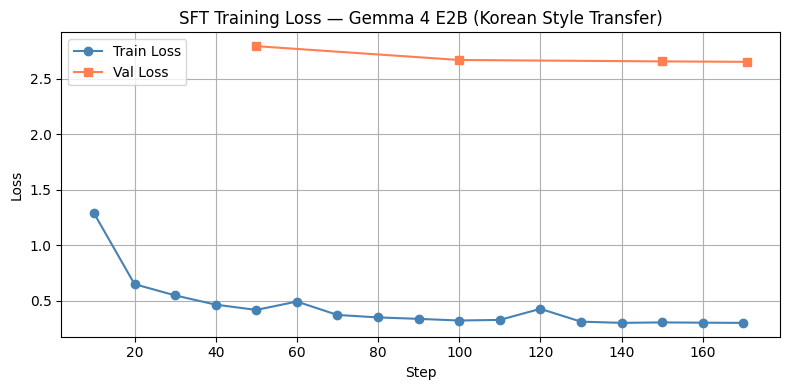

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

steps_train = [x["step"] for x in log_history if "loss" in x]
losses_train = [x["loss"] for x in log_history if "loss" in x]

steps_val = [x["step"] for x in log_history if "eval_loss" in x]
losses_val = [x["eval_loss"] for x in log_history if "eval_loss" in x]

plt.figure(figsize=(8, 4))
plt.plot(steps_train, losses_train, marker="o", color="steelblue", label="Train Loss")
plt.plot(steps_val, losses_val, marker="s", color="coral", label="Val Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("SFT Training Loss — Gemma 4 E2B (Korean Style Transfer)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

## Loss 곡선 시각화

Train Loss는 step 10에서 1.28로 시작해 step 171에서 0.30으로 꾸준히 감소했다.
Val Loss는 step 50에서 2.75로 시작해 step 171에서 2.64로 완만하게 감소했다.

| Step | Training Loss | Validation Loss |
|------|--------------|----------------|
| 50   | 0.414973     | 2.795446       |
| 100  | 0.319323     | 2.670775       |
| 150  | 0.302221     | 2.657995       |
| 171  | 0.297969     | 2.654020       |

### 분석 — 과적합/과소적합 판단

정상 학습으로 판단한다.

- Train Loss가 꾸준히 감소 → 모델이 스타일 패턴을 학습하고 있음
- Val Loss도 함께 감소, 올라가지 않음 → 과적합 신호 없음
- Train/Val Loss 격차가 큰 것은 `train_on_responses_only` 구조적 특성
  (Train Loss는 assistant 응답 토큰만, Val Loss는 전체 시퀀스 기준으로 계산)

**하이퍼파라미터는 변경하지 않았다.**

# 8. 망각체크

In [ ]:
# 망각 체크용 질문
GENERAL = {
    "망각체크_수도": "대한민국의 수도는 어디인가요?",
    "망각체크_번역": '"I love learning Korean"을 한국어로 번역해주세요.',
}

def ask_general(model, tokenizer, question, max_new_tokens=200):
    msgs = [{"role": "user", "content": [{"type": "text", "text": question}]}]
    inputs = tokenizer.apply_chat_template(
        msgs, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt"
    ).to("cuda")
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.95,
        top_k=64,
    )
    return tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

print("=" * 60)
print("망각 체크 — Before (베이스 모델)")
print("=" * 60)
for name, prompt in GENERAL.items():
    print(f"\n[{name}]")
    print(f"출력: {ask_general(base_model, tokenizer, prompt)}")
    print("-" * 60)

print("=" * 60)
print("망각 체크 — After (파인튜닝 모델)")
print("=" * 60)
for name, prompt in GENERAL.items():
    print(f"\n[{name}]")
    print(f"출력: {ask_general(ft_model, tokenizer, prompt)}")
    print("-" * 60)

망각 체크 — Before (베이스 모델)

[망각체크_수도]
출력: 대한민국의 수도는 **세종특별자치시**입니다.
------------------------------------------------------------

[망각체크_번역]
출력: "I love learning Korean"을 한국어로 번역하면 다음과 같습니다.

**저는 한국어를 배우는 것을 정말 좋아해요.**

좀 더 자연스러운 표현으로는 다음과 같이 말할 수 있습니다.

* **한국어를 배우는 게 너무 좋아요.** (가장 자연스러운 표현)
* **한국어를 공부하는 걸 정말 즐겨요.** (학습 자체를 즐긴다는 뉘앙스)
* **한국어 공부하는 게 재미있어요.** (흥미를 강조)
------------------------------------------------------------
망각 체크 — After (파인튜닝 모델)

[망각체크_수도]
출력: 대한민국의 수도는 **서울**입니다.
------------------------------------------------------------

[망각체크_번역]
출력: "I love learning Korean"을 한국어로 번역하면 다음과 같은 표현들이 가능합니다.

**가장 자연스럽고 일반적인 표현:**

* 한국어 공부하는 거 너무 좋아! (가장 구어체적이고 친근한 표현)
* 한국어 배우는 거 정말 좋아. (좀 더 정중하고 일반적인 표현)
* 한국어 공부하는 거 완전 재밌어! (흥미를 강조하는 표현)

**좀 더 격식 있는 표현:**

* 한국어를 배우는 것을 매우 즐깁니다. (공식적인 자리나 글에서 사용)
* 한국어 학습에 열정적입니다. (학습에 대한 강한 의지를 나타냄)

**좀 더 캐주얼한 표현:**

* 한국어 완전 꿀잼이야! (매우 캐주얼하고 친구들 사이에서 사용)
* 한국어 배우는 거 완전 꿀팁이야! (배움의 즐거움을
---------------------------------------------------------

## 망각 체크 (Forgetting Check)

파인튜닝 후 일반 언어 능력이 유지되는지 확인한다.
스타일 지시 없이 일반 질문만 입력해 Before/After 출력을 비교했다.

| 질문 | Before (베이스 모델) | After (파인튜닝 모델) | 평가 |
|---|---|---|---|
| 대한민국의 수도는 어디인가요? | 세종특별자치시 (오답) | 서울 (정답) | ✅ 오히려 개선 |
| "I love learning Korean"을 한국어로 번역해주세요. | "저는 한국어를 배우는 것을 정말 좋아해요." + 다양한 표현 제시 | "한국어 공부하는 거 너무 좋아!" + 격식·캐주얼 표현 제시 | ✅ 능력 유지 |

### 분석

LoRA 방식으로 본체 가중치를 동결한 채 어댑터만 학습했기 때문에 파국적 망각이 발생하지 않았다.
번역 능력은 Before/After 모두 자연스러운 번역과 다양한 표현을 제시하는 수준을 유지했다.

수도 질문에서 Before "세종"(오답) → After "서울"(정답)로 개선됐으나,
이는 파인튜닝의 직접적 효과가 아닌 샘플링 과정의 확률적 차이로 판단된다.

# 9. After

In [ ]:
FastModel.for_inference(ft_model)


print("=" * 60)
print("After (파인튜닝 모델)")
print("=" * 60)
for name, prompt in PROMPTS.items():
    print(f"\n[{name}]\n입력: {prompt[:50]}...")
    print(f"출력: {ask(ft_model, tokenizer, prompt)}")
    print("-" * 60)

After (파인튜닝 모델)

[사례1_할머니말투]
입력: 예시 문장: "아이고, 우리 강아지 똥강아지 귀여워라."
작성할 내용: 할머니가 손자에게 ...
출력: 아이고, 우리 강아지 똥강아지 귀여워라. 할미가 옛날이야기 하나 해줄까?

옛날 옛날에 말이야, 할매가 똥강아지를 키웠어. 그 똥강아지가 얼마나 귀여웠는지 몰라. 털도 복슬복슬하고, 꼬리도 길어서 누가 만져주면 얼마나 좋아했는지.

그런데 말이야, 그 똥강아지가 가끔 똥을 싸버려서 할매가 얼마나 속상했는지. "아이고, 이 똥강아지!" 하면서도 한 번도 혼내지 않았지. 그저 조용히 받아주기만 했어.

그러다 어느 날, 그 똥강아지가 똥을 너무 많이 싸서 할매가 너무 놀랐지 뭐야. "아이고, 우리 강아지!" 하면서도 그 모습을 보고는 더 사랑스러워졌
------------------------------------------------------------

[사례2_인터넷슬랭]
입력: 예시 문장: "갑자기 TMI인데 어제 꿀잼 드라마 정주행했음ㅋㅋ"
작성할 내용: 새로 나온...
출력: ㅇㅇㅇ님들 요즘 뭐 보냐?? ㅋㅋㅋ

나 어제 완전 꽂힌 드라마 있는데 완전 꿀잼임ㅠㅠㅠ

제목은 '달빛 아래 우리'인데 완전 로맨스+힐링+성장물 섞여서 갓띵작 각임ㅇㅇ

주인공 혜진이랑 민준이 완전 썸타고 있는데 서로의 삶에 긍정적인 영향을 줌ㅋㅋㅋ

솔직히 처음엔 좀 느린맛이었는데 3화쯤 되니까 완전 몰입됨ㅠㅠㅠ

특히 혜진이 자기 자신을 사랑하게 되는 과정이 너무 힐링됨ㅠㅠㅠ

민준이도 혜진한테 많이 의지하는데 그게 또 설렘 포인트임ㅋㅋㅋ

근데 갑자기 떡밥 풀려서 다음 주 완전 기대됨ㅠㅠㅠ

혹시 아직 안 봤으면 무조건 정주행 ㄱㄱㅇㅇ

댓글들 보니까 다들 혜진이
------------------------------------------------------------


## After 실험 (파인튜닝 모델)

파인튜닝 후 동일한 프롬프트로 출력을 확인한다.

---

### 사례 1 — 할머니 말투

**입력**

예시 문장: "아이고, 우리 강아지 똥강아지 귀여워라."
작성할 내용: 할머니가 손자에게 옛날 이야기를 들려주는 상황

**출력**

아이고, 우리 강아지 똥강아지 귀여워라. 할미가 옛날이야기 하나 해줄까?

옛날 옛날에 말이야, 할매가 똥강아지를 키웠어. 그 똥강아지가 얼마나 귀여웠는지 몰라.
털도 복슬복슬하고, 꼬리도 길어서 누가 만져주면 얼마나 좋아했는지.

그런데 말이야, 그 똥강아지가 가끔 똥을 싸버려서 할매가 얼마나 속상했는지.
"아이고, 이 똥강아지!" 하면서도 한 번도 혼내지 않았지. 그저 조용히 받아주기만 했어.

**평가:** △ 부분 개선

"할미가", "말이야", "할매가" 등 구어체 말투는 학습됐으나,
손자에게 옛날이야기를 들려주는 주제보다 강아지 이야기로 흘러가는 내용 일관성이 부족했다.

---

### 사례 2 — 인터넷 슬랭

**입력**

예시 문장: "갑자기 TMI인데 어제 꿀잼 드라마 정주행했음ㅋㅋ"
작성할 내용: 새로 나온 드라마에 대해 온라인 커뮤니티에서 의견을 나누는 글

**출력**

ㅇㅇㅇ님들 요즘 뭐 보냐?? ㅋㅋㅋ

나 어제 완전 꽂힌 드라마 있는데 완전 꿀잼임ㅠㅠㅠ
제목은 '달빛 아래 우리'인데 완전 로맨스+힐링+성장물 섞여서 갓띵작 각임ㅇㅇ

주인공 혜진이랑 민준이 완전 썸타고 있는데 서로의 삶에 긍정적인 영향을 줌ㅋㅋㅋ
솔직히 처음엔 좀 느린맛이었는데 3화쯤 되니까 완전 몰입됨ㅠㅠㅠ

혹시 아직 안 봤으면 무조건 정주행 ㄱㄱㅇㅇ

**평가:** ✅ 개선

"ㅠㅠㅠ", "ㄱㄱ", "갓띵작", "꿀잼" 등 커뮤니티 말투가 자연스럽게 생성됐다.
Before에서 마크다운 헤더와 정형화된 게시글 형식이 나오던 것과 명확히 대비된다.
가설("정책 미정렬 문제 → SFT로 교정 가능")이 이 사례에서 확인됐다.